# Exploratory Data Analysis
The purpose of this notebook is to explore the dataset.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### 1. Read in the raw dataframe

In [15]:
df = pd.read_parquet(r'..\data\raw\final-raw-merged-data.parquet')

In [16]:
df.head(2)

,date,TMAX,TMIN,AWND,PRCP,BOT_TEMP_C,SURF_TEMP_C
0,1939-07-01,76.0,63.0,NaN,0.0,19.1,19.4
1,1939-07-02,74.0,65.0,NaN,0.0,19.5,19.8


#### 2. Assess for missing values

In [17]:
len(df)

31596

In [18]:
df.isnull().sum()

date               0
TMAX               6
TMIN               6
AWND           16259
PRCP               3
BOT_TEMP_C      1983
SURF_TEMP_C      899
dtype: int64

In [19]:
(df.isnull().mean() * 100).round(1)

date            0.0
TMAX            0.0
TMIN            0.0
AWND           51.5
PRCP            0.0
BOT_TEMP_C      6.3
SURF_TEMP_C     2.8
dtype: float64

AWND has over 50% null values. For that reason it will be dropped from the dataset.

In [20]:
df.drop(columns='AWND', inplace=True)

For the other columns, we will interpolate with the mean of the most adjacent rows for the given column to fill the null.

In [21]:
list(df.columns)

['date', 'TMAX', 'TMIN', 'PRCP', 'BOT_TEMP_C', 'SURF_TEMP_C']

In [22]:
float_cols = ['TMAX', 'TMIN', 'PRCP', 'BOT_TEMP_C', 'SURF_TEMP_C']

df[float_cols] = df[float_cols].interpolate(axis=0)

In [23]:
df.isnull().sum()

date           0
TMAX           0
TMIN           0
PRCP           0
BOT_TEMP_C     0
SURF_TEMP_C    0
dtype: int64

#### 3. Individual Variable Analysis

TMAX
count    31596.0
mean        70.7
std          6.8
min         46.0
25%         66.0
50%         70.0
75%         75.0
max        111.0
Name: TMAX, dtype: float64


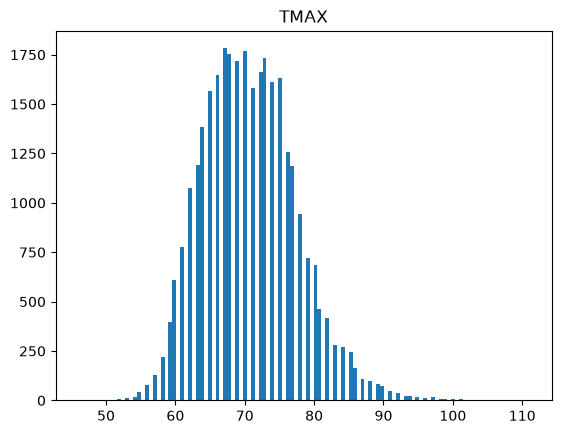

----------

TMIN
count    31596.0
mean        57.3
std          7.4
min         29.0
25%         52.0
50%         58.0
75%         63.0
max         78.0
Name: TMIN, dtype: float64


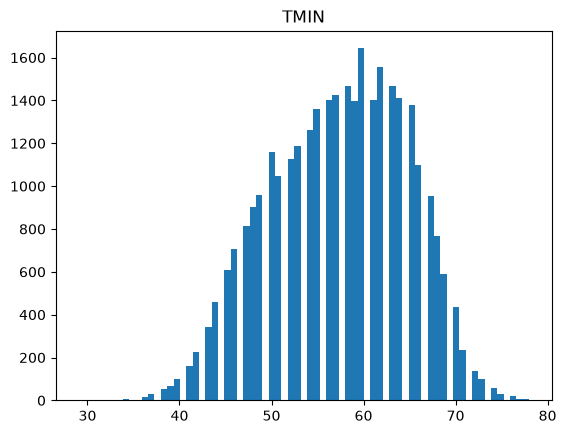

----------

PRCP
count    31596.0
mean         0.0
std          0.1
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          2.7
Name: PRCP, dtype: float64


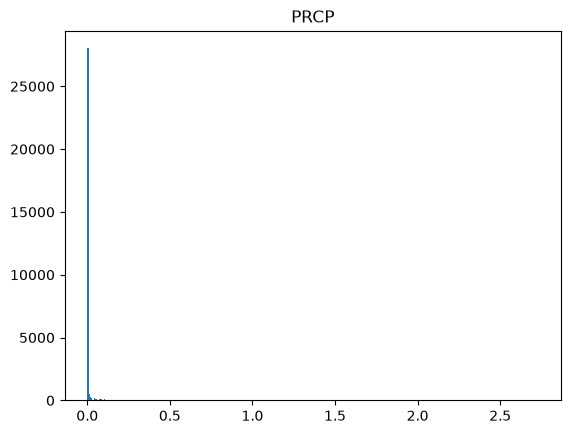

----------

BOT_TEMP_C
count    31596.0
mean        16.8
std          2.4
min         10.0
25%         14.9
50%         16.5
75%         18.5
max         26.0
Name: BOT_TEMP_C, dtype: float64


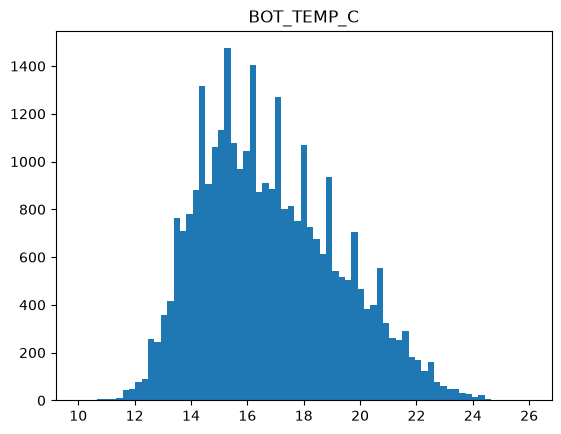

----------

SURF_TEMP_C
count    31596.0
mean        17.4
std          2.7
min         10.1
25%         15.2
50%         17.1
75%         19.4
max         26.4
Name: SURF_TEMP_C, dtype: float64


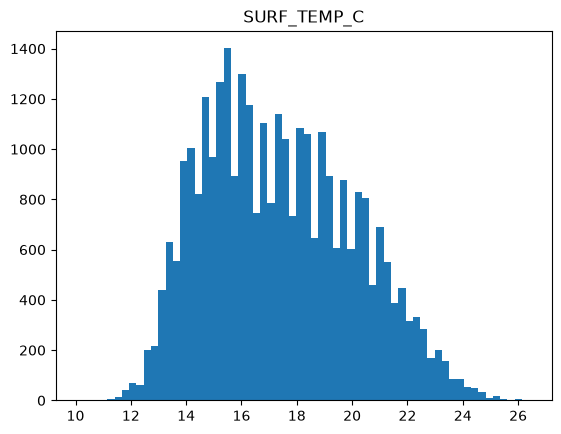

----------



In [24]:
for col in float_cols:
    print(col)
    print(df[col].describe().round(1).T)
    plt.title(col)
    plt.hist(df[col], bins='auto')
    plt.show()

    print('----------\n')


#### Assessing for correlation

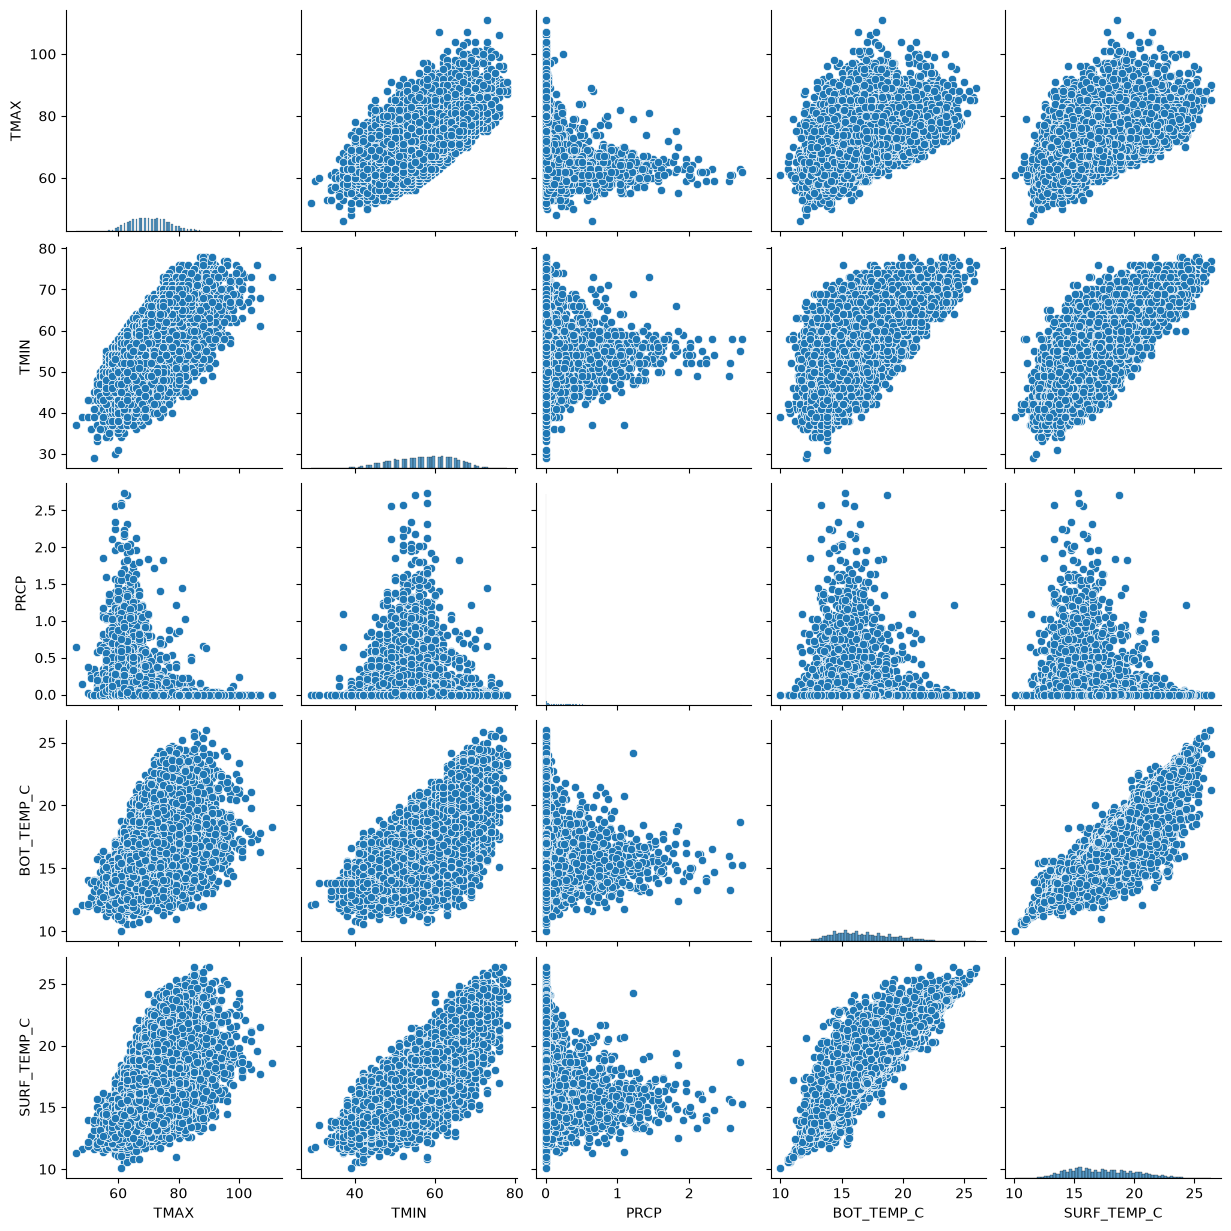

In [27]:
sns.pairplot(df)
plt.show()

In [28]:
corr_matrix = df.corr()

In [29]:
corr_matrix

,date,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C
date,1.000000,-0.000654,0.151106,-0.005869,0.194462,0.195825
TMAX,-0.000654,1.000000,0.599508,-0.216343,0.523735,0.619876
TMIN,0.151106,0.599508,1.000000,-0.084774,0.740225,0.837605
PRCP,-0.005869,-0.216343,-0.084774,1.000000,-0.108565,-0.133116
BOT_TEMP_C,0.194462,0.523735,0.740225,-0.108565,1.000000,0.920822
SURF_TEMP_C,0.195825,0.619876,0.837605,-0.133116,0.920822,1.000000


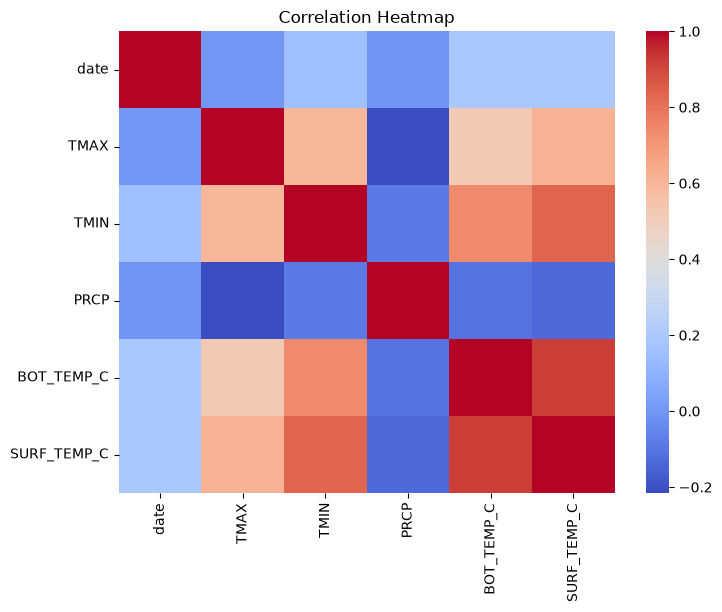

In [32]:
plt.figure(figsize=(8,6))
plt.title('Correlation Heatmap')
sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".1f")
plt.show()